In [ ]:
ilmport kagglehub

# Download latest version
path = kagglehub.dataset_download("osmankagankurnaz/acne-dataset-in-yolov8-format")

print("Path to dataset files:", path)

100%|██████████| 33.9M/33.9M [00:00<00:00, 251MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1


In [ ]:
import os

print(os.listdir(path))

['data-2']


In [ ]:
import os

real_path = f"{path}/data-2"
print(os.listdir(real_path))

['data.yaml', 'train', 'test', 'valid']


In [ ]:
print(os.listdir(f"{real_path}/train"))
print(os.listdir(f"{real_path}/valid"))

['labels', 'images']
['labels', 'images']


In [ ]:
import yaml

yaml_path = f"{real_path}/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Before Fix:", data)

# ✅ Fix paths
data['train'] = f"{real_path}/train/images"
data['val'] = f"{real_path}/valid/images"
data['test'] = f"{real_path}/test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("After Fix:", data)

Before Fix: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['Acne'], 'roboflow': {'workspace': 'osman-kagan-kurnaz', 'project': 'skin-detection-uvj1f', 'version': 8, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/osman-kagan-kurnaz/skin-detection-uvj1f/dataset/8'}}
After Fix: {'train': '/root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/train/images', 'val': '/root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/valid/images', 'test': '/root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images', 'nc': 1, 'names': ['Acne'], 'roboflow': {'workspace': 'osman-kagan-kurnaz', 'project': 'skin-detection-uvj1f', 'version': 8, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/osman-kagan-kurnaz/skin-detection-uvj1f/dataset/8'}}


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # fast model

model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0  # GPU
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, f

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b52c45b6240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

View Training Results (Graphs)

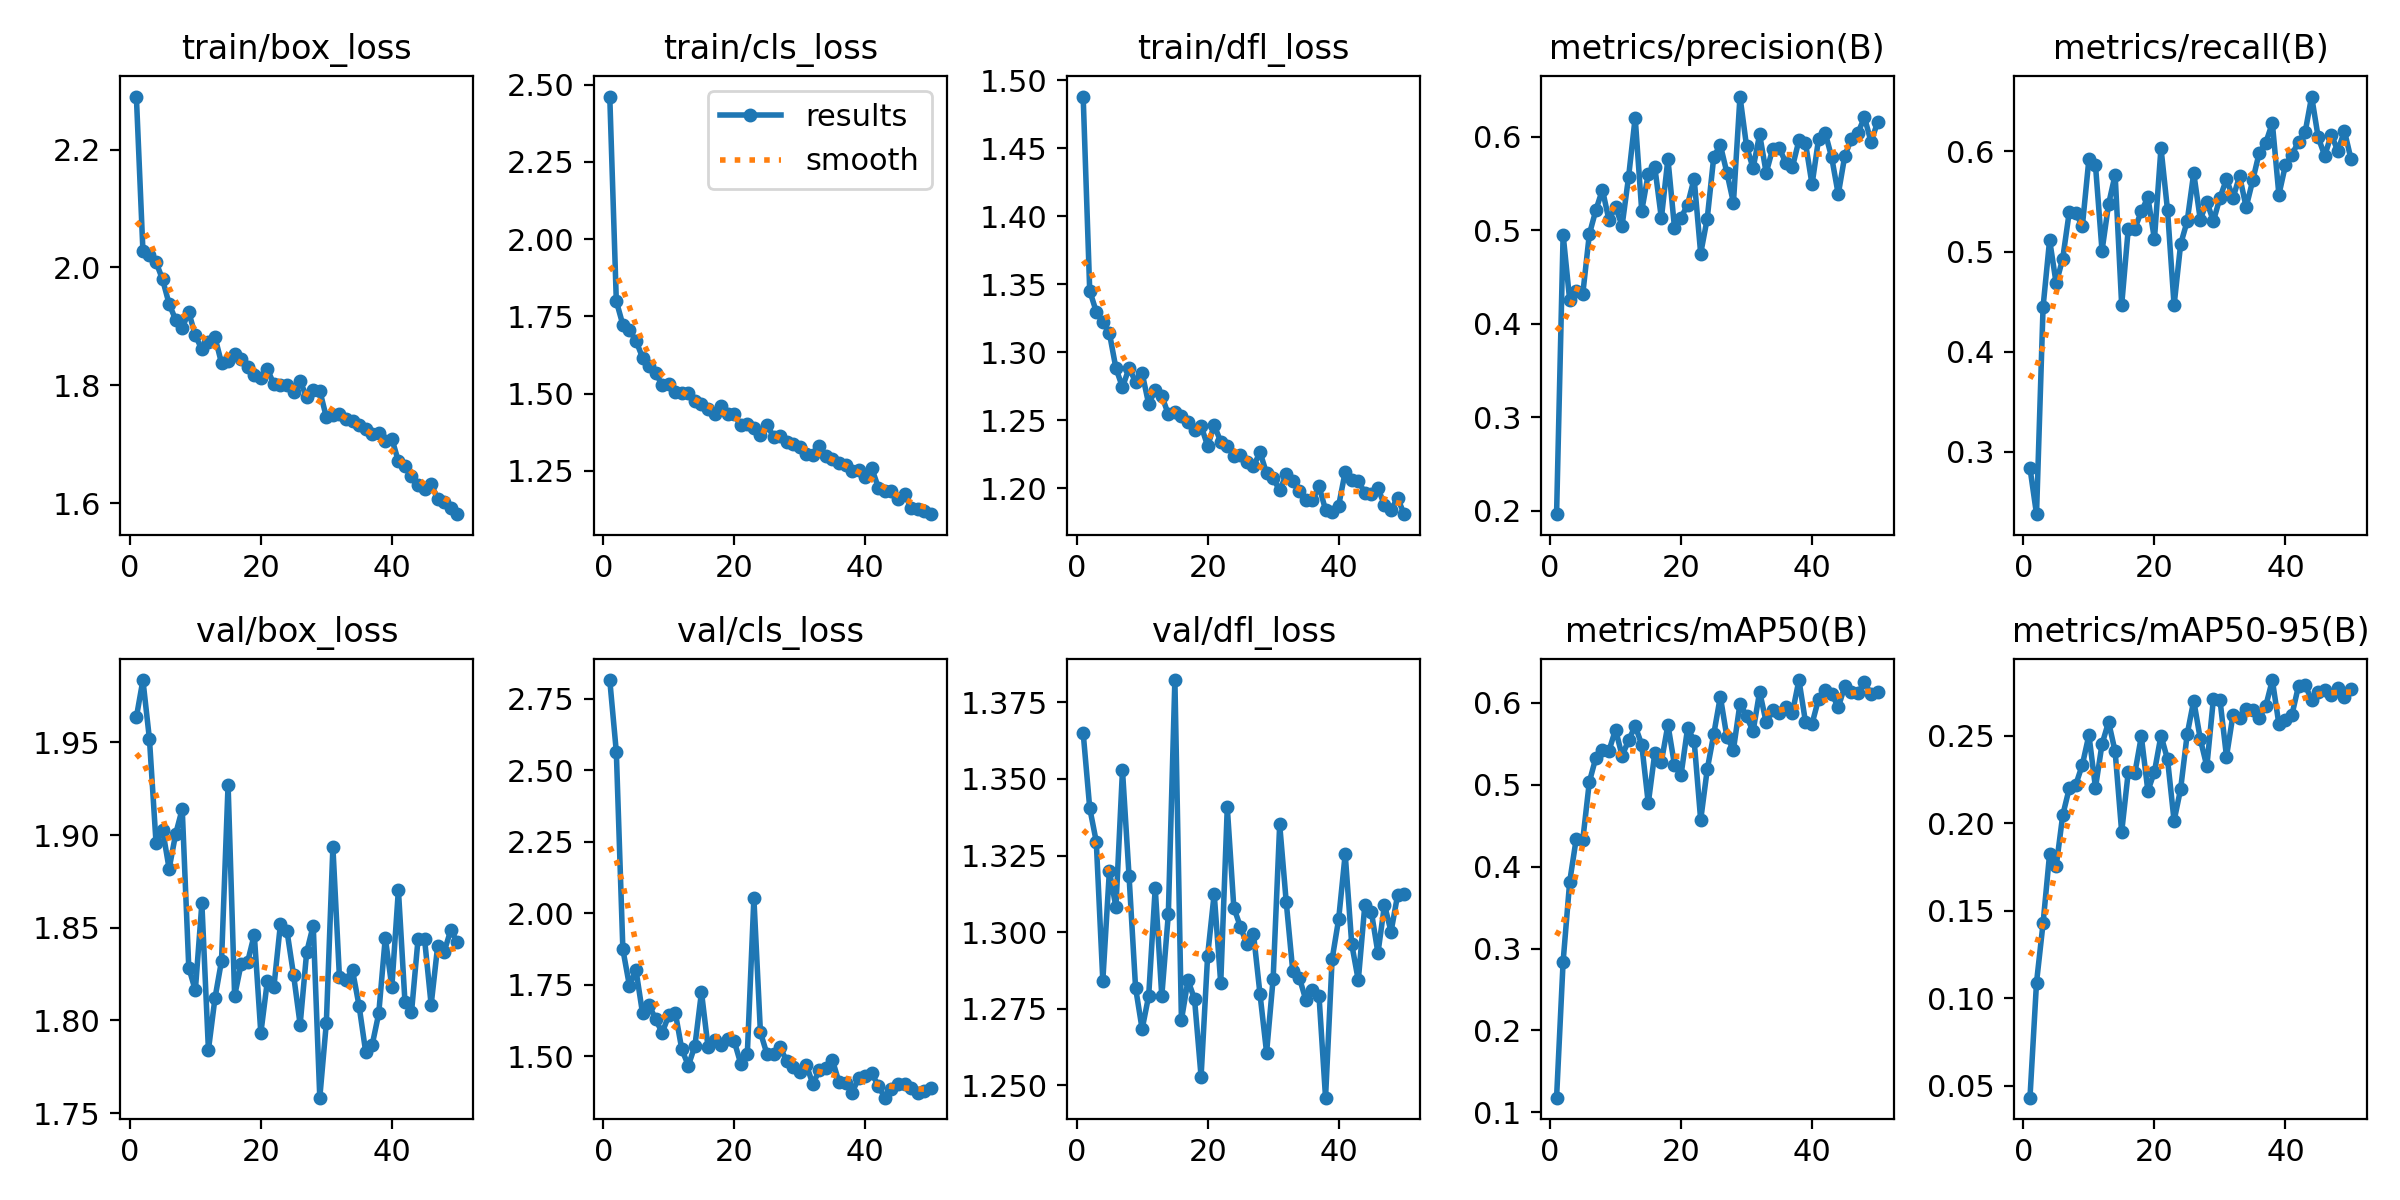

In [ ]:
from IPython.display import Image

Image("runs/detect/train/results.png")

Detailed Evaluation Metrics

In [ ]:
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 691.1±442.2 MB/s, size: 46.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/valid/labels.cache... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 13.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4s/it 5.7s
                   all         56        643      0.579      0.632      0.623      0.282
Speed: 14.0ms preprocess, 20.6ms inference, 0.0ms loss, 9.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.6231290081891
mAP50-95: 0.28160921362637786
Precision: 0.578764015450743
Recall: 0.6324950307313393


Predict on Test Images

In [ ]:
results = model.predict(
    source=f"{real_path}/test/images",
    conf=0.25,
    save=True
)


image 1/48 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-102_jpeg.rf.d15b34dc9a1e69aa996118a4c1a173ef.jpg: 640x640 1 Acne, 7.3ms
image 2/48 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-105_jpeg.rf.e9b2ecfb4afb0217f046179f125242d2.jpg: 640x640 1 Acne, 7.2ms
image 3/48 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-112_jpeg.rf.a03c796422719e964f46be1c118861bc.jpg: 640x640 15 Acnes, 7.2ms
image 4/48 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-128_jpg.rf.e3826584d02398d0f1d915cf3365a959.jpg: 640x640 5 Acnes, 7.2ms
image 5/48 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-140_jpg.rf.785b2c29676c422c6a1cdbe6708f86e8.jpg: 640x640 27 Acnes, 7.2ms
image 6/48 

Show 5 Prediction Images

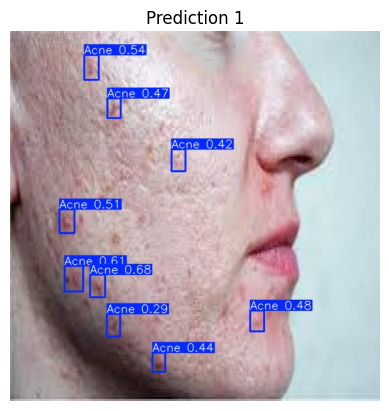

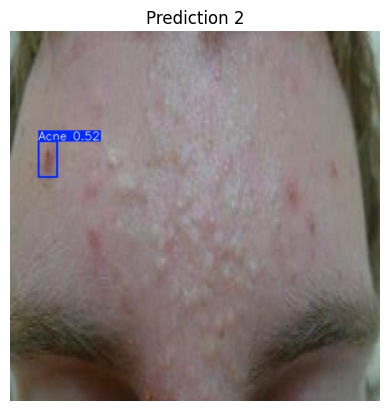

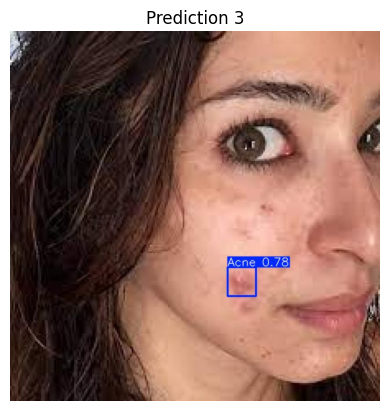

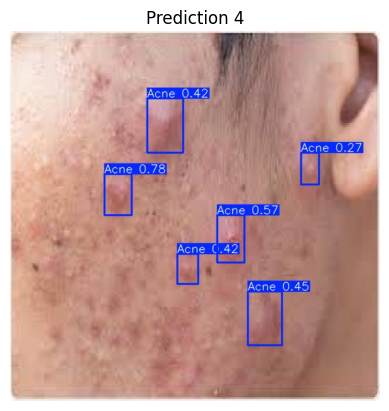

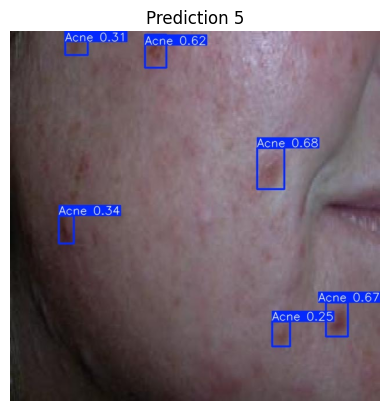

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

pred_path = "runs/detect/predict"

images = os.listdir(pred_path)

for i in range(5):
    img = cv2.imread(os.path.join(pred_path, images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"Prediction {i+1}")
    plt.axis('off')
    plt.show()

Show Bounding Boxes + Confidence

In [ ]:
for r in results[:5]:
    print("Boxes:", r.boxes.xyxy)
    print("Classes:", r.boxes.cls)
    print("Confidence:", r.boxes.conf)
    print("------")

Boxes: tensor([[376.4117, 408.1089, 425.2467, 458.3292]], device='cuda:0')
Classes: tensor([0.], device='cuda:0')
Confidence: tensor([0.7838], device='cuda:0')
------
Boxes: tensor([[ 49.7373, 190.7686,  81.6163, 252.2266]], device='cuda:0')
Classes: tensor([0.], device='cuda:0')
Confidence: tensor([0.5162], device='cuda:0')
------
Boxes: tensor([[371.4231, 237.4726, 407.6699, 293.9852],
        [234.5349, 157.3391, 272.6259, 218.6866],
        [397.2040,  59.8621, 443.0632, 134.8381],
        [345.7114,  26.6082, 390.5744,  82.8409],
        [300.2748,  67.6328, 348.0835, 140.1338],
        [177.2200, 144.6085, 204.0823, 189.4552],
        [288.6821, 300.2792, 334.7003, 365.0352],
        [ 23.9220, 185.7718,  52.0148, 226.0806],
        [ 20.4722, 110.4238,  66.1393, 191.6115],
        [280.9306, 157.0567, 328.7632, 235.4066],
        [623.3737,  60.3342, 640.0000, 111.7010],
        [420.7953, 434.5038, 449.2564, 480.4716],
        [405.4036,  75.0269, 441.2093, 132.0318],
        [

Confusion Matrix

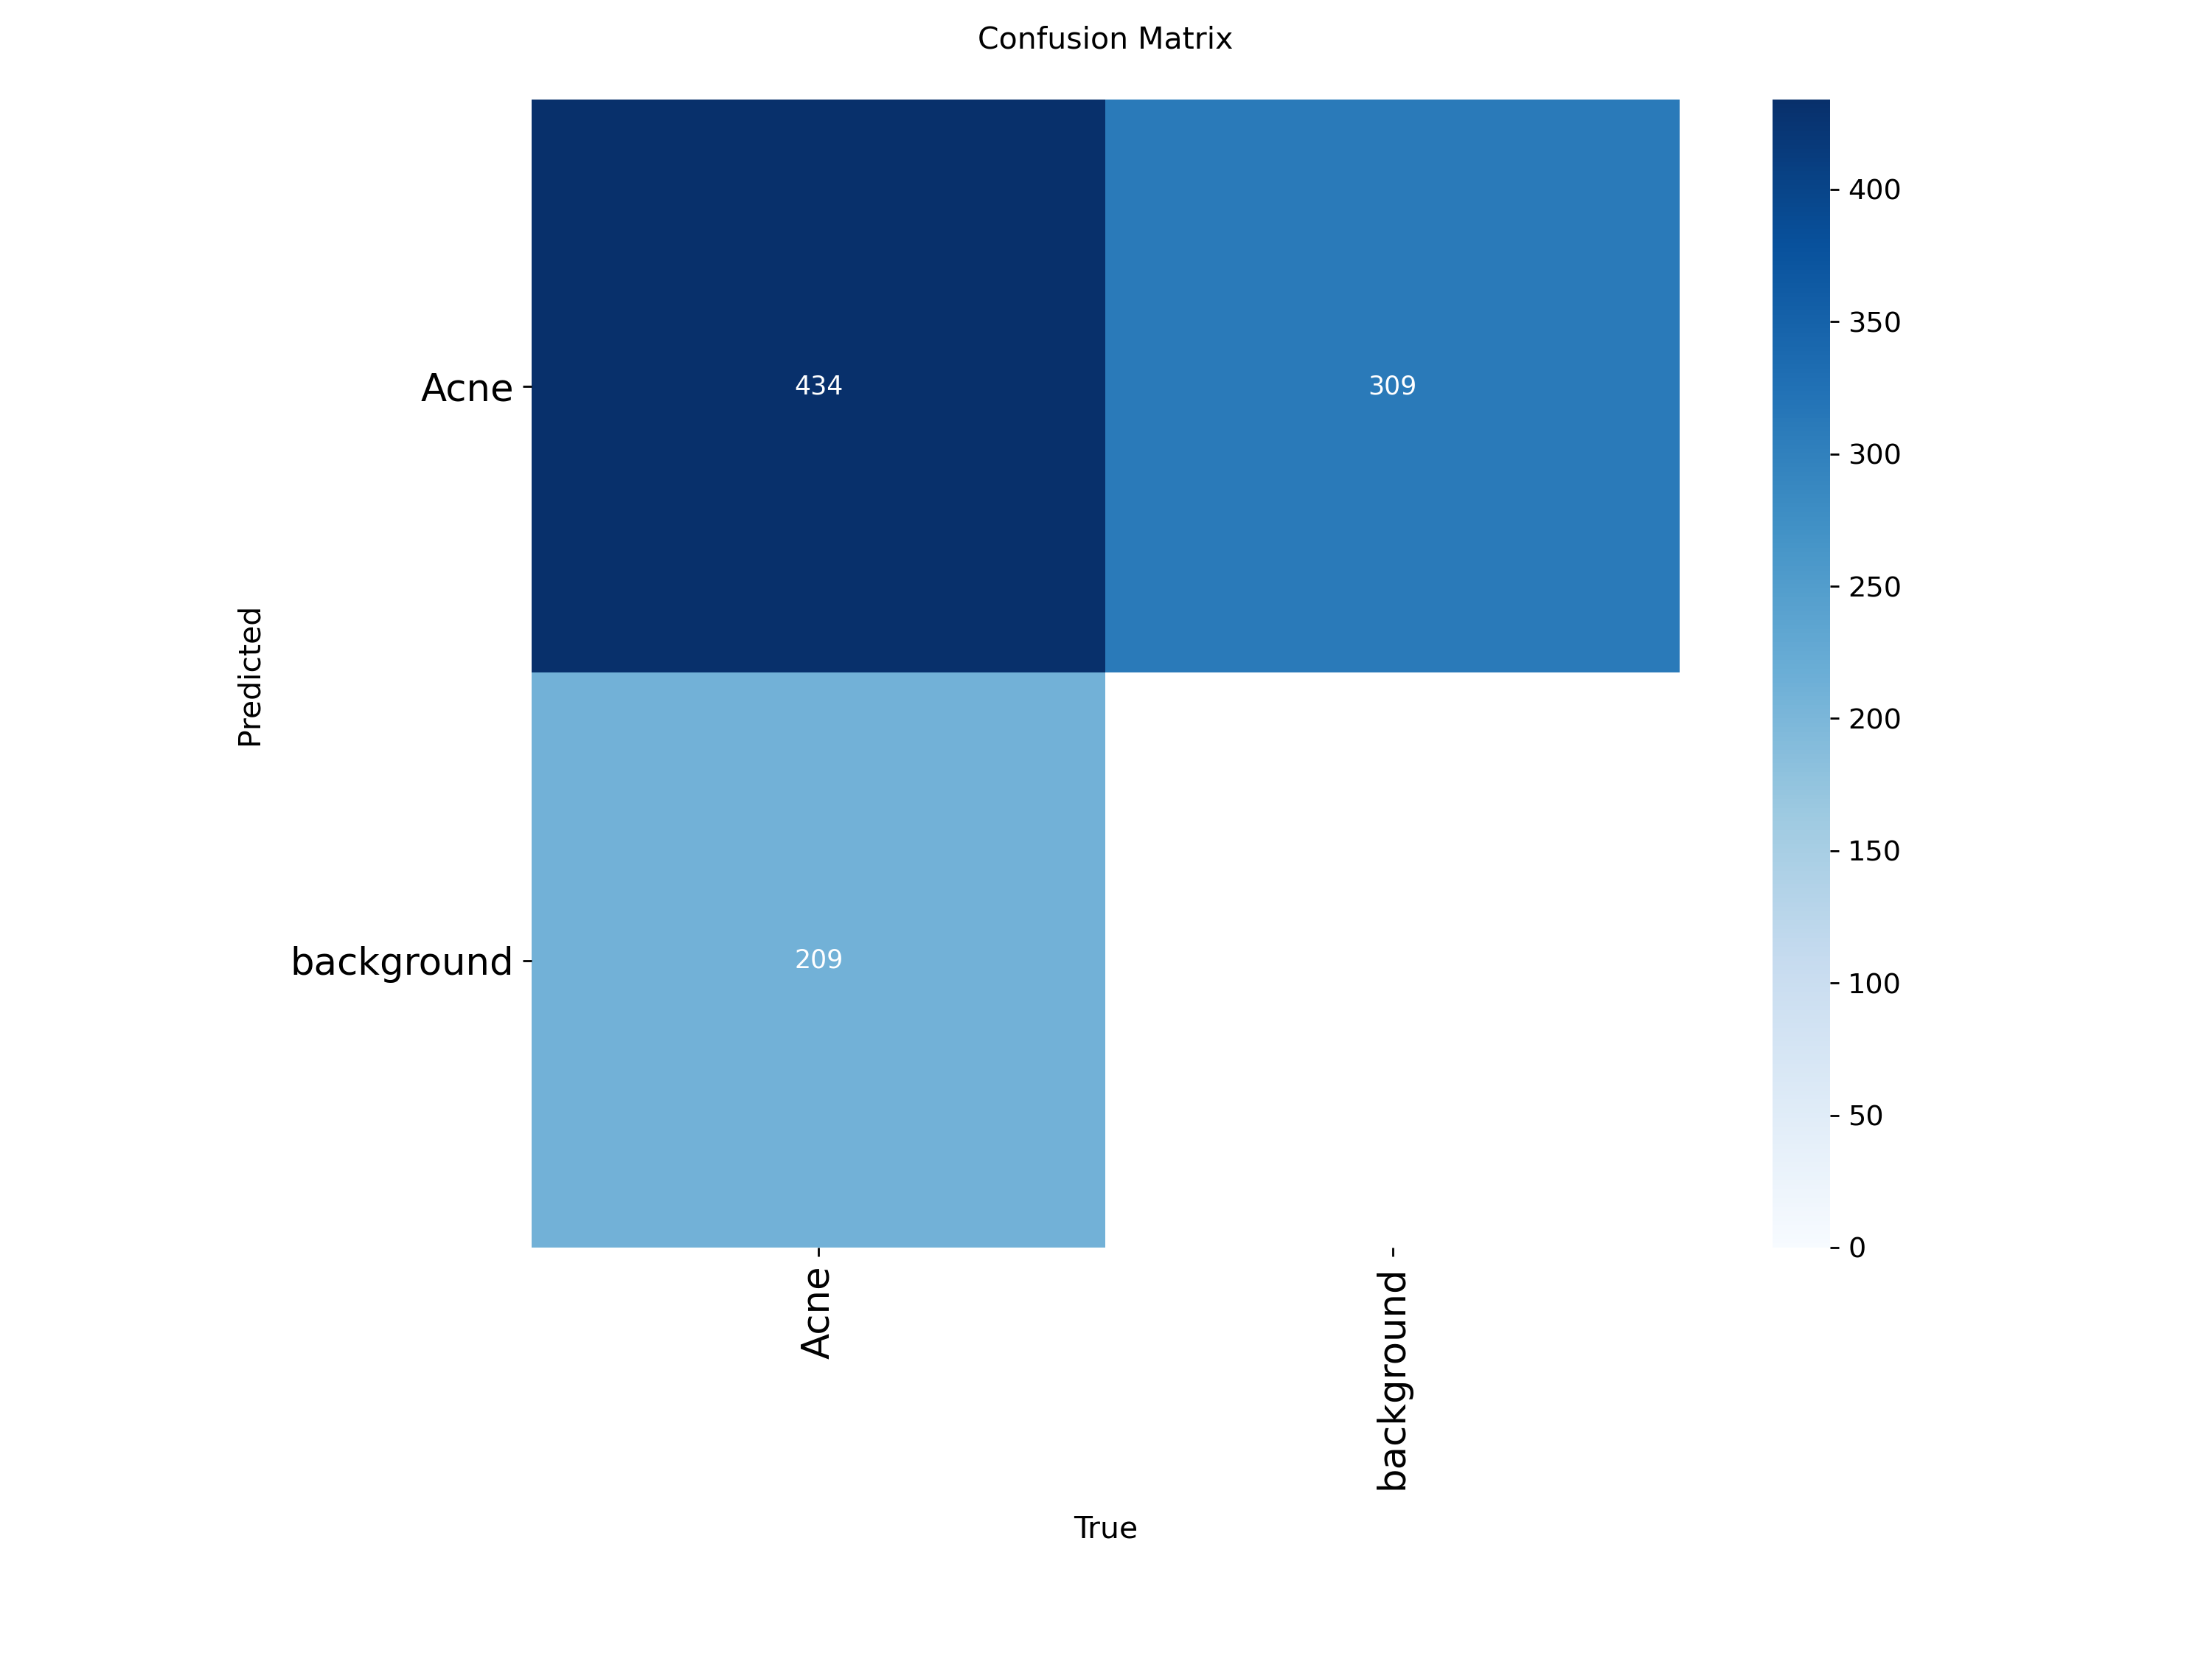

In [ ]:
Image("runs/detect/train/confusion_matrix.png")

PR Curve

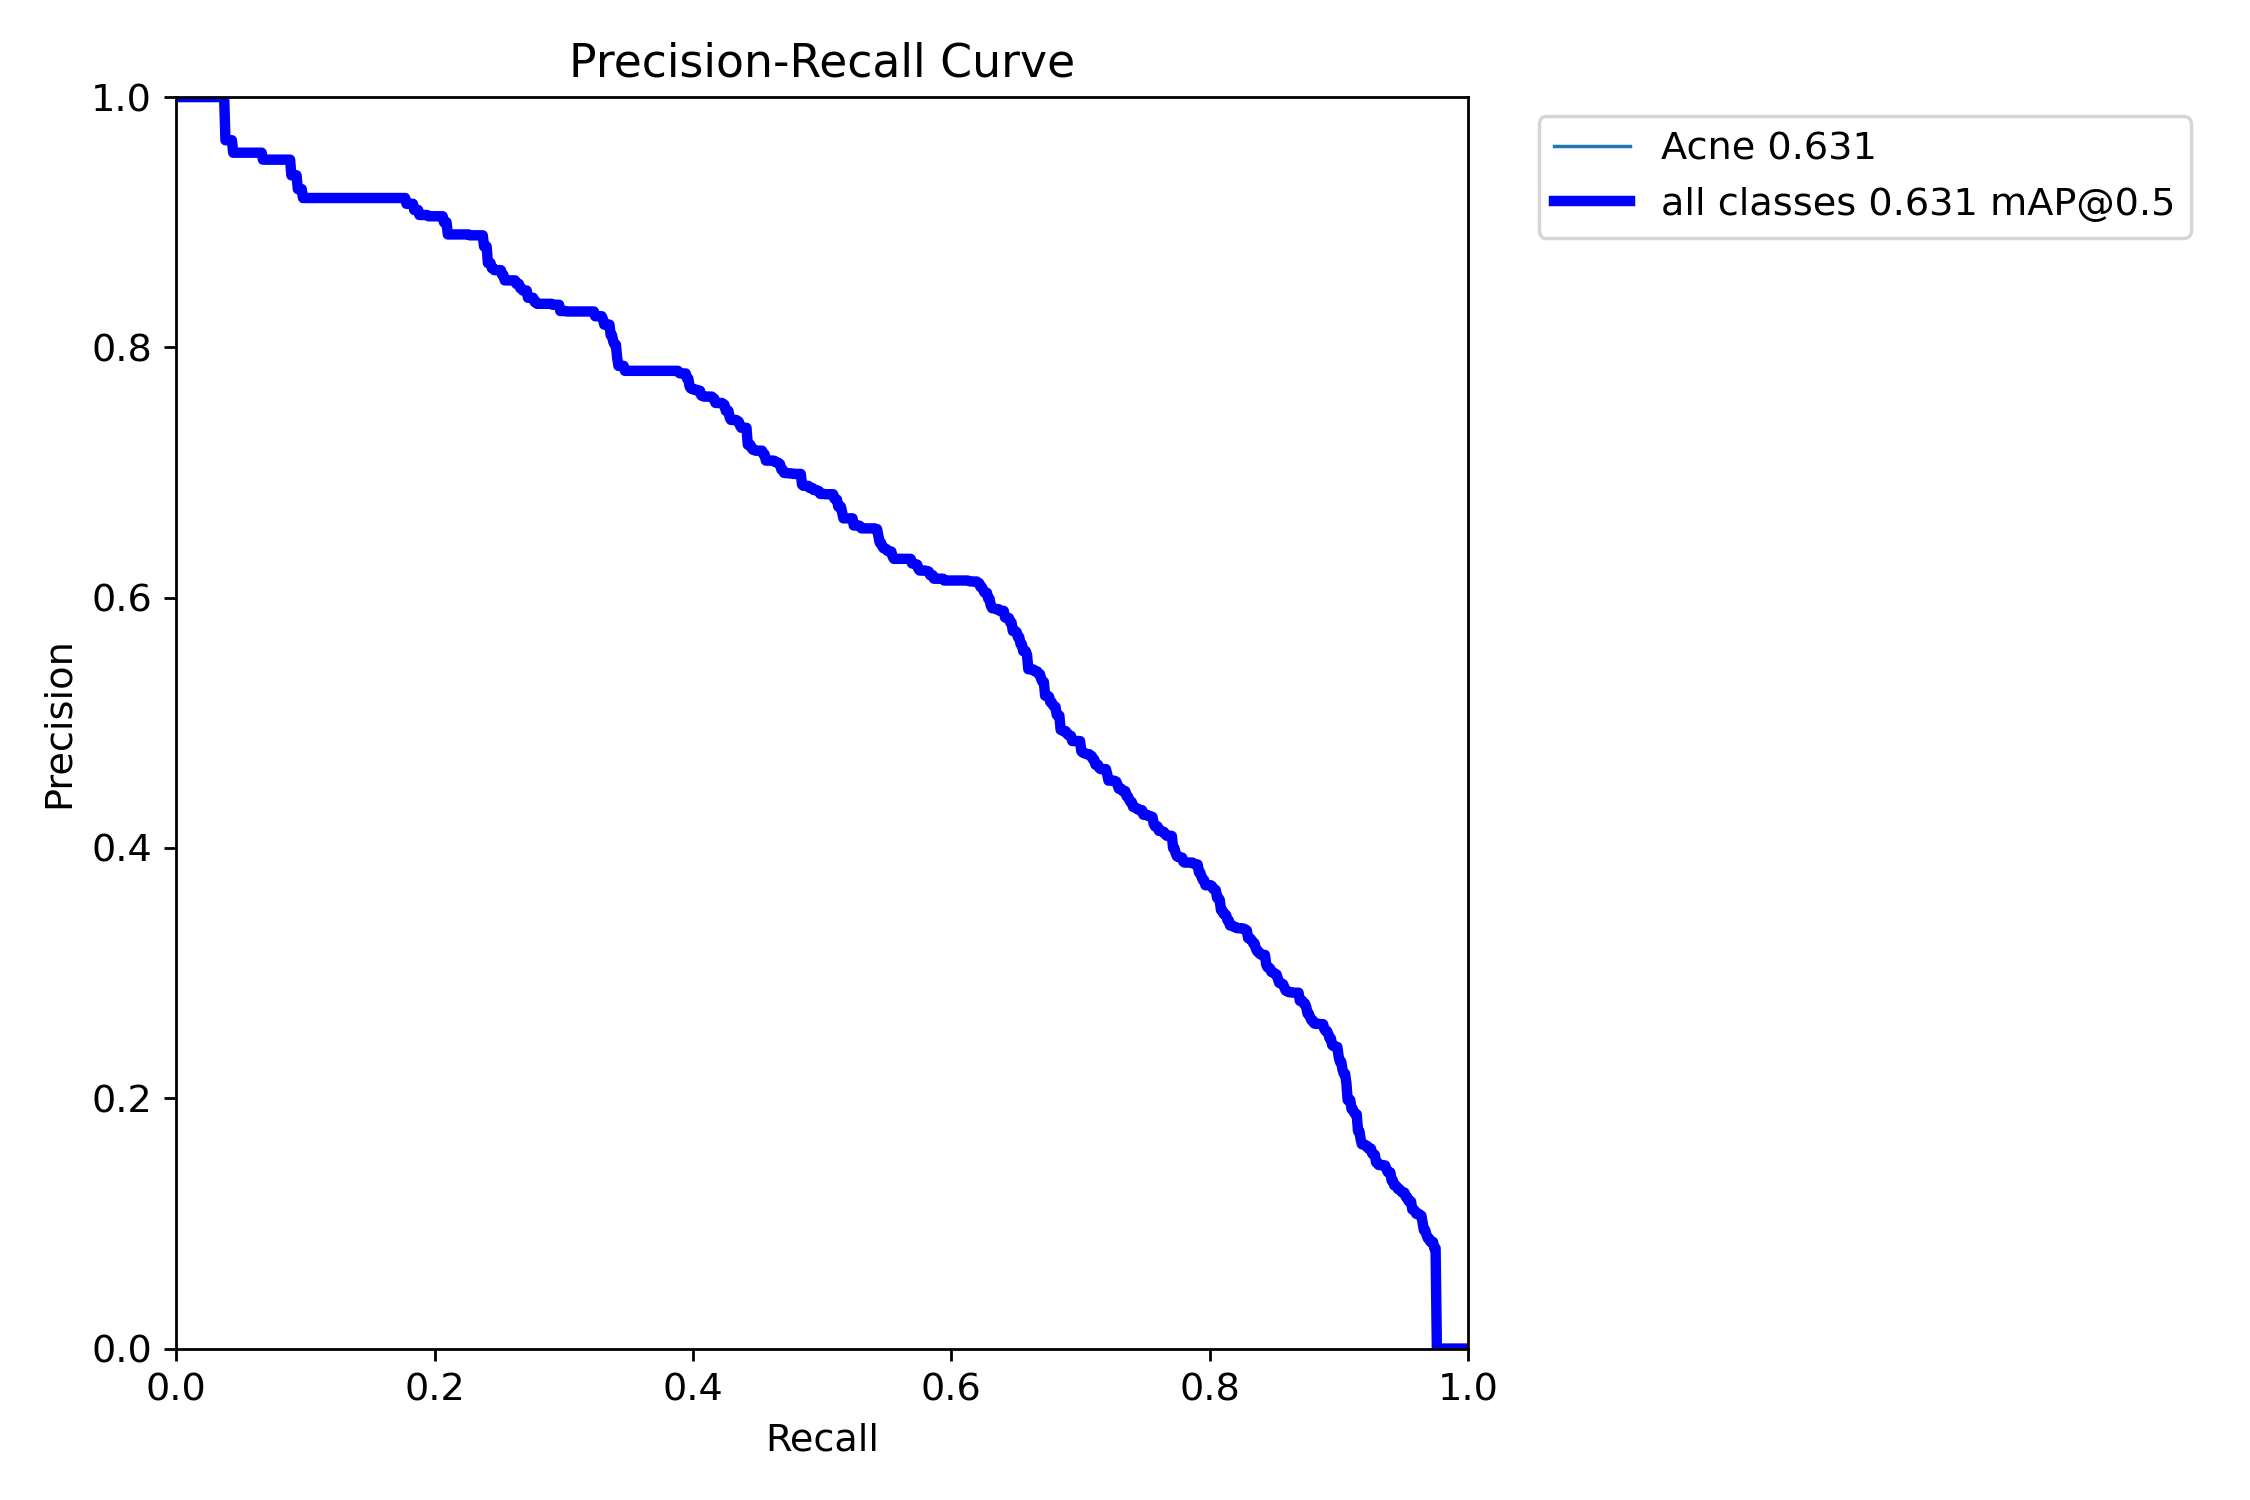

In [ ]:
from IPython.display import Image
Image("runs/detect/train/BoxPR_curve.png")

F1 Curve

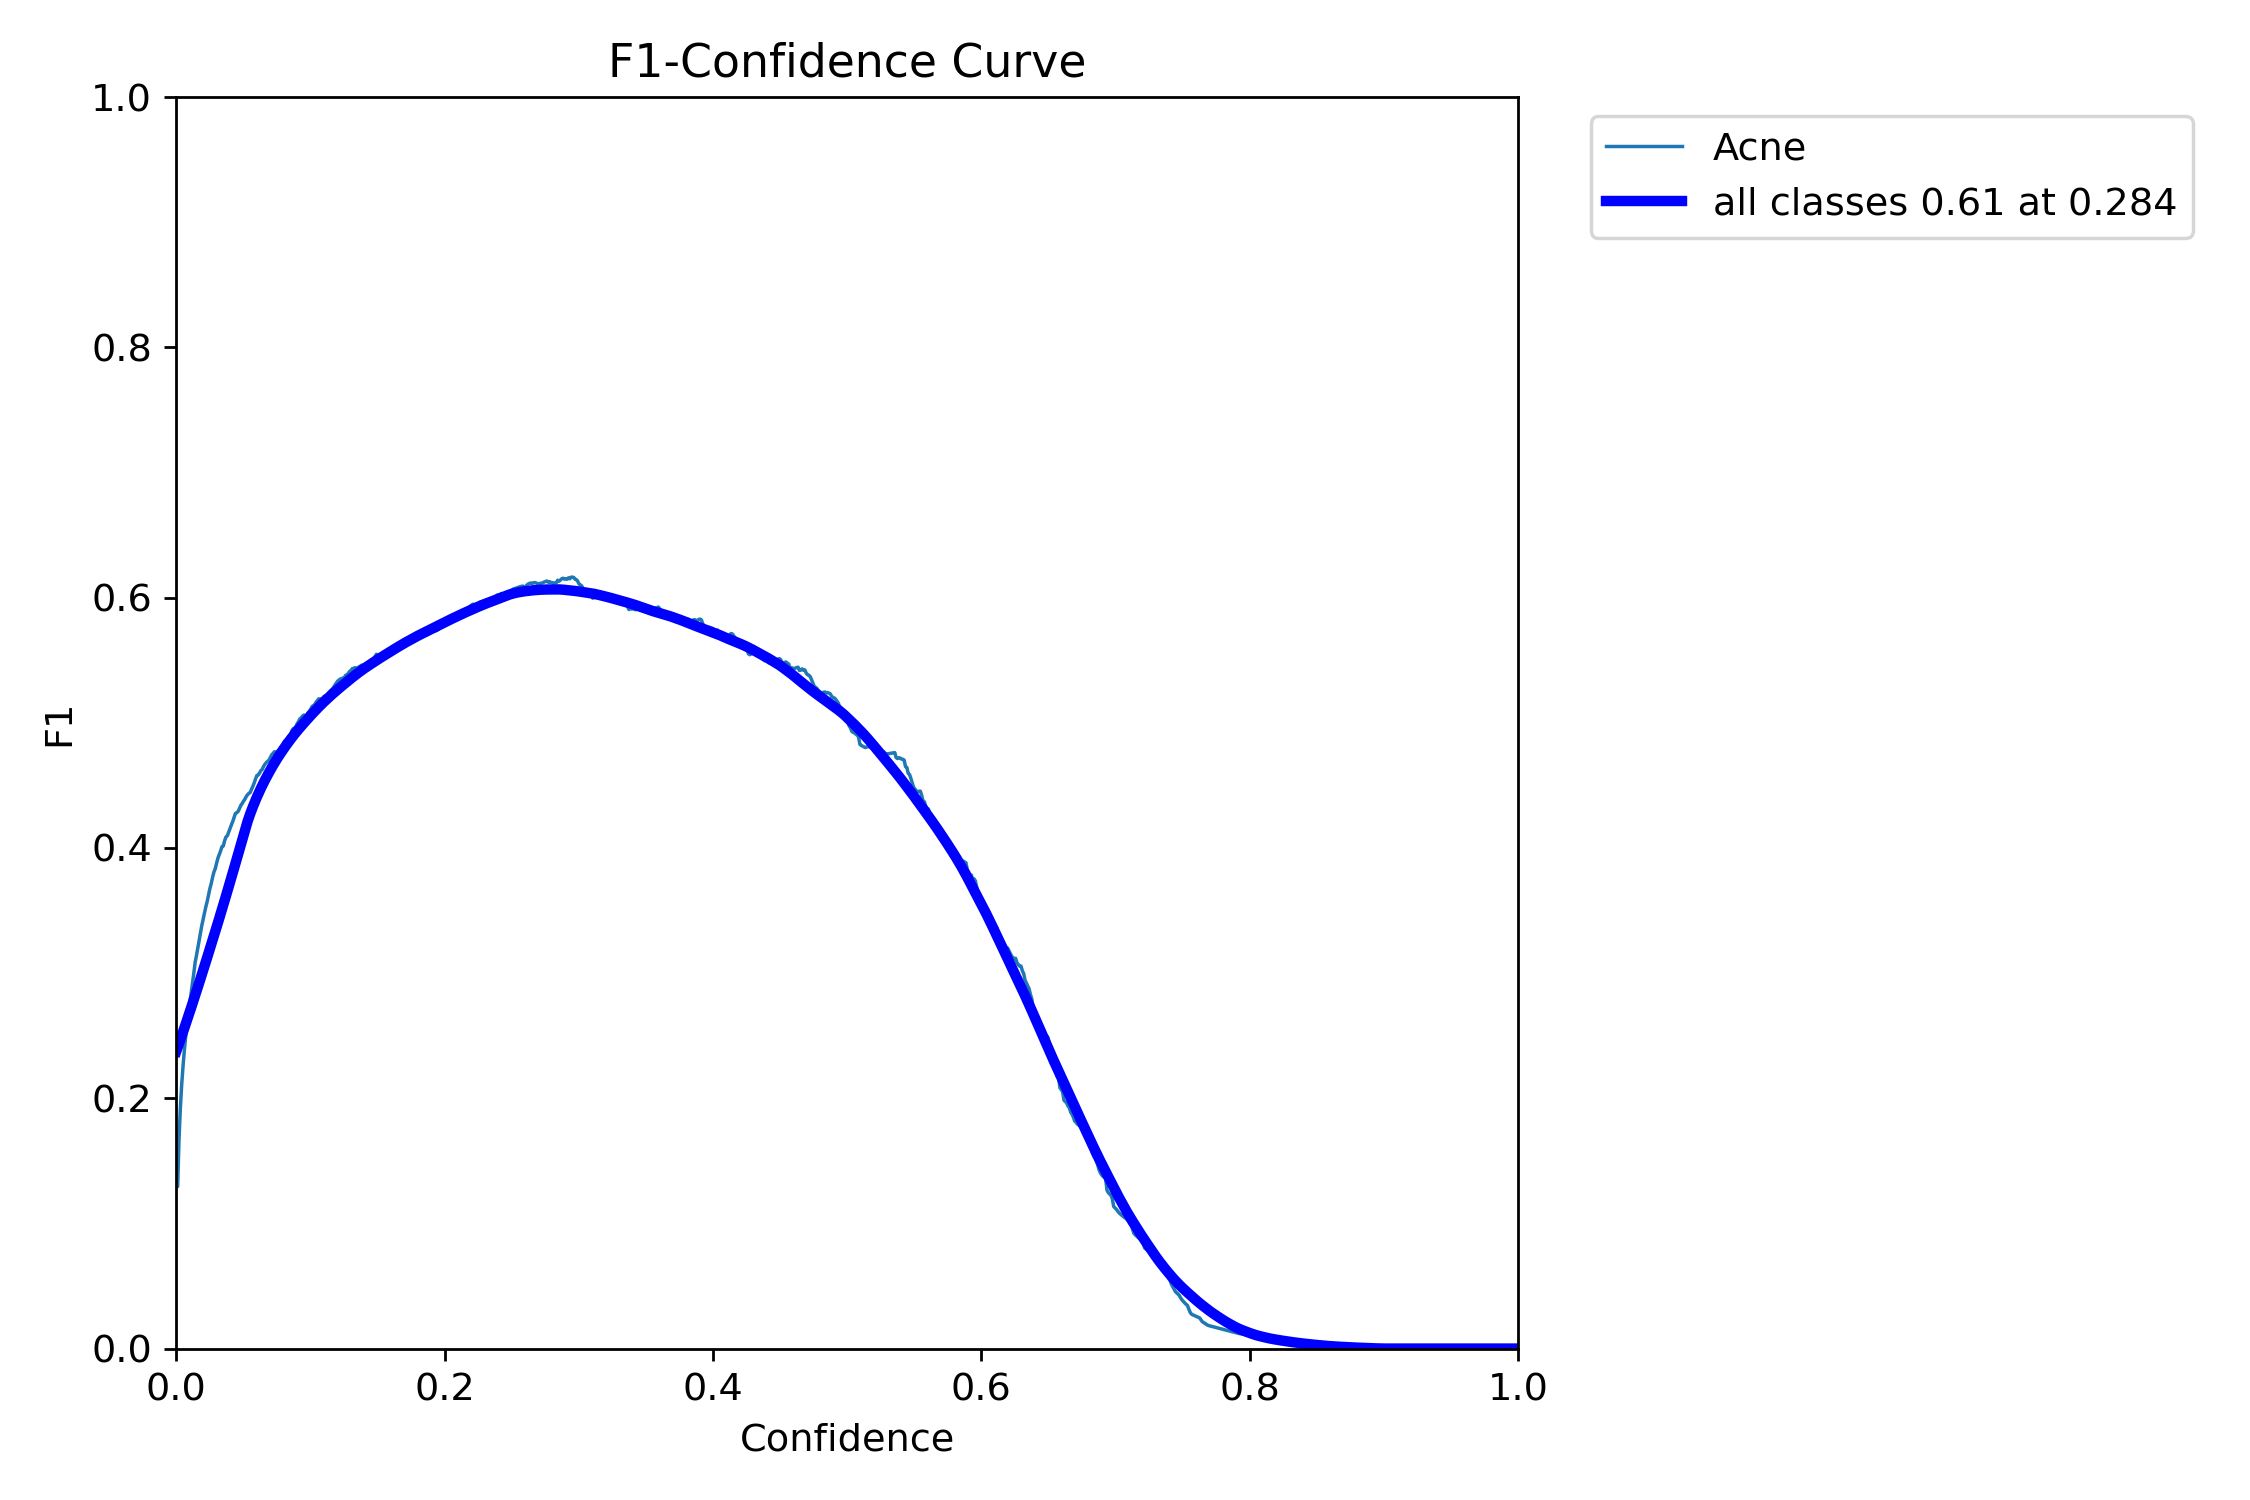

In [ ]:
from IPython.display import Image
Image("runs/detect/train/BoxF1_curve.png")

Best Model Path

In [ ]:
print("/content/runs/detect/train/weights/best.pt")

/content/runs/detect/train/weights/best.pt


Load Best Model for Inference

In [ ]:
best_model = YOLO("runs/detect/train/weights/best.pt")

Single Image Prediction (Clean Demo)

In [ ]:
img_path = f"{real_path}/test/images/" + os.listdir(f"{real_path}/test/images")[0]

best_model.predict(
    source=img_path,
    show=True,
    conf=0.3
)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-49_jpeg.rf.3c951af43df31b304067823e836ec20b.jpg: 640x640 8 Acnes, 16.6ms
Speed: 5.2ms preprocess, 16.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Acne'}
 obb: None
 orig_img: array([[[171, 167, 186],
         [169, 165, 184],
         [156, 152, 171],
         ...,
         [209, 201, 178],
         [209, 201, 178],
         [208, 200, 177]],
 
        [[173, 169, 188],
         [171, 167, 186],
         [157, 153, 172],
         ...,
         [210, 202, 179],
         [209, 201, 178],
         [208, 200, 177]],
 
        [[171, 167, 186],
         [168, 164, 183],
         [155, 151, 170],
         ...,
         [210, 202, 179],
         [209, 201, 178],
         [208, 200, 177]],
 
        ...,
 
        [[164, 163, 167],
         [166, 165, 169],
         [160, 159, 163],
         ...,
         [236, 228, 205],
         [236, 228, 205],
         [236, 228, 205]],
 
        [[160, 159, 163],
         [162, 161, 165],
         [157, 156, 160],
         ...,
         [237, 229, 

Save Predictions with Confidence Overlay

In [ ]:
best_model.predict(
    source=img_path,
    save=True,
    conf=0.3
)


image 1/1 /root/.cache/kagglehub/datasets/osmankagankurnaz/acne-dataset-in-yolov8-format/versions/1/data-2/test/images/acne-49_jpeg.rf.3c951af43df31b304067823e836ec20b.jpg: 640x640 8 Acnes, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Acne'}
 obb: None
 orig_img: array([[[171, 167, 186],
         [169, 165, 184],
         [156, 152, 171],
         ...,
         [209, 201, 178],
         [209, 201, 178],
         [208, 200, 177]],
 
        [[173, 169, 188],
         [171, 167, 186],
         [157, 153, 172],
         ...,
         [210, 202, 179],
         [209, 201, 178],
         [208, 200, 177]],
 
        [[171, 167, 186],
         [168, 164, 183],
         [155, 151, 170],
         ...,
         [210, 202, 179],
         [209, 201, 178],
         [208, 200, 177]],
 
        ...,
 
        [[164, 163, 167],
         [166, 165, 169],
         [160, 159, 163],
         ...,
         [236, 228, 205],
         [236, 228, 205],
         [236, 228, 205]],
 
        [[160, 159, 163],
         [162, 161, 165],
         [157, 156, 160],
         ...,
         [237, 229, 